## Step 1: Import Libraries

In [ ]:
import tensorflow as tf
import zipfile
from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

## Step 2: Set Up Kaggle API Token

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('KGAT_398ee2c21c92e2ed6268cd2e01b125ee')

!chmod 600 /root/.kaggle/access_token
!pip install kaggle -q

## Step 3: Download the Dataset Directly into Colab

In [ ]:
!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
100% 3.58G/3.58G [00:34<00:00, 112MB/s]



## Step 4: Check the Downloaded Folders

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'dataset', 'sample_data']


## Step 5: Explore the Dataset Folder Structure

In [ ]:
import os
print(os.listdir('/content/dataset'))

['train', 'test', 'dataset']


## Step 6: Check Inside train, test, and nested dataset Folders

In [ ]:
import os

print("Inside train:", os.listdir('/content/dataset/train'))
print("Inside test:", os.listdir('/content/dataset/test'))
print("Inside nested dataset:", os.listdir('/content/dataset/dataset'))

Inside train: ['freshapples', 'freshbanana', 'rottenoranges', 'rottenbanana', 'rottenapples', 'freshoranges']
Inside test: ['freshapples', 'freshbanana', 'rottenoranges', 'rottenbanana', 'rottenapples', 'freshoranges']
Inside nested dataset: ['train', 'test']


## Step 7: Load the Data (6-Class Classification)
Since we have 6 categories (fresh/rotten × apple/banana/orange), we use `class_mode='categorical'` instead of `binary`.

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


## Step 8: Custom CNN Model (Built From Scratch, 6 Classes)
Three Conv2D + MaxPooling layers extract features from the images (edges, colors, texture). `Flatten` converts those features into a single line, then `Dense` layers make the decision. The final layer has 6 units with `softmax` activation, giving a probability for each of the 6 classes.

In [ ]:
custom_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

## Step 9: Compile the Custom CNN
`categorical_crossentropy` is the loss function used for multi-class problems (more than 2 classes).

In [ ]:
custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 10: Load Pretrained MobileNetV2 (Transfer Learning)
`MobileNetV2` is already trained on millions of images (ImageNet dataset). `include_top=False` means we're not using its original final layers — we'll add our own. `trainable = False` freezes the pretrained part so it won't be retrained.

In [ ]:
base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Step 11: Add Custom Layers on Top (6 Classes)

In [ ]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

## Step 12: Compile the Transfer Learning Model

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,358 (8.93 MB)

 Trainable params: 82,374 (321.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 13: Train the Custom CNN
Both models are trained on the same training/validation data so their results can be directly compared.

In [ ]:
history_cnn = custom_cnn.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.6700 - loss: 0.8767 - val_accuracy: 0.8889 - val_loss: 0.3689
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.8562 - loss: 0.4191 - val_accuracy: 0.8967 - val_loss: 0.2980
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.8932 - loss: 0.3151 - val_accuracy: 0.9371 - val_loss: 0.2009
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.9142 - loss: 0.2456 - val_accuracy: 0.9435 - val_loss: 0.1526
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.9199 - loss: 0.2271 - val_accuracy: 0.9582 - val_loss: 0.1076
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - accuracy: 0.9325 - loss: 0.1932 - val_accuracy: 0.9697 - val_loss: 0.0847
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.9418 - loss: 0.1657 - val_accuracy: 0.9559 - val_loss: 0.1193
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.9462 - loss: 0.1481 - val_accu

## Step 14: Train the Transfer Learning Model

In [ ]:
history_transfer = transfer_model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 184s 651ms/step - accuracy: 0.8621 - loss: 0.3979 - val_accuracy: 0.9761 - val_loss: 0.0749
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 168s 615ms/step - accuracy: 0.9474 - loss: 0.1577 - val_accuracy: 0.9848 - val_loss: 0.0459
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 168s 614ms/step - accuracy: 0.9637 - loss: 0.1097 - val_accuracy: 0.9871 - val_loss: 0.0384
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 169s 621ms/step - accuracy: 0.9694 - loss: 0.0916 - val_accuracy: 0.9927 - val_loss: 0.0240
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 206s 636ms/step - accuracy: 0.9789 - loss: 0.0642 - val_accuracy: 0.9936 - val_loss: 0.0191
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 167s 613ms/step - accuracy: 0.9805 - loss: 0.0571 - val_accuracy: 0.9954 - val_loss: 0.0146
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 169s 618ms/step - accuracy: 0.9810 - loss: 0.0519 - val_accuracy: 0.9949 - val_loss: 0.0162
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 166s 608ms/step - accuracy: 0.9842 -

## Step 15: Plot Accuracy and Loss Comparison
This compares how both models performed during training — validation accuracy and validation loss, side by side.

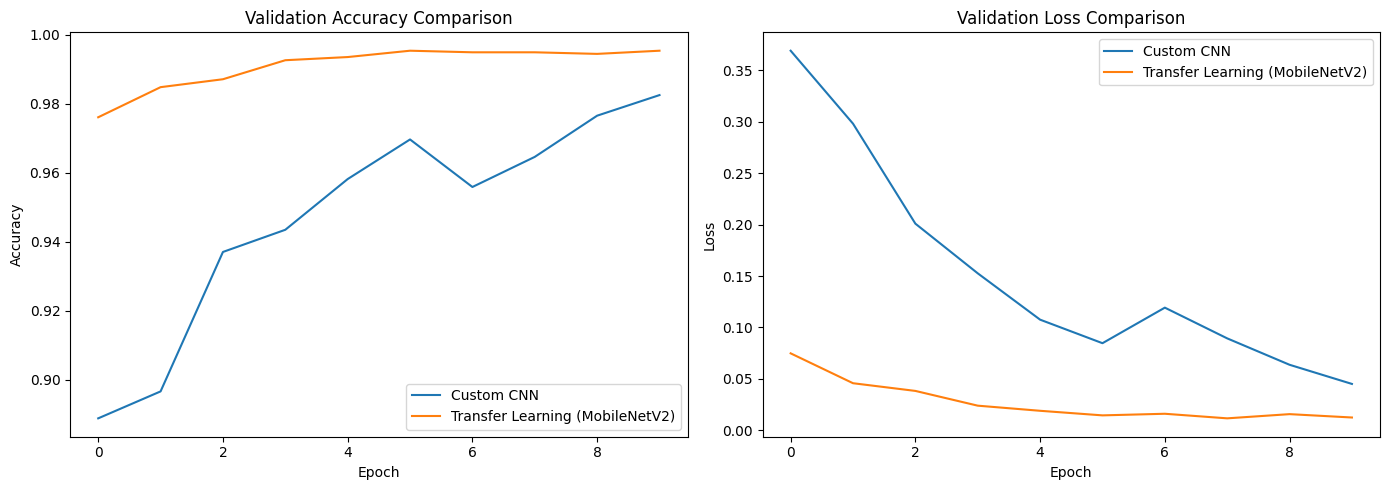

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_cnn.history['val_accuracy'], label='Custom CNN')
axes[0].plot(history_transfer.history['val_accuracy'], label='Transfer Learning (MobileNetV2)')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss comparison
axes[1].plot(history_cnn.history['val_loss'], label='Custom CNN')
axes[1].plot(history_transfer.history['val_loss'], label='Transfer Learning (MobileNetV2)')
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 16: Evaluate Both Models on Test Data
This checks performance on completely unseen images (the `test` folder we saw earlier).

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    '/content/dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

cnn_test_loss, cnn_test_acc = custom_cnn.evaluate(test_data)
print(f"Custom CNN Test Accuracy: {cnn_test_acc*100:.2f}%")

transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_data)
print(f"Transfer Learning Test Accuracy: {transfer_test_acc*100:.2f}%")

Found 2698 images belonging to 6 classes.
85/85 ━━━━━━━━━━━━━━━━━━━━ 37s 436ms/step - accuracy: 0.9648 - loss: 0.0875
Custom CNN Test Accuracy: 96.48%
85/85 ━━━━━━━━━━━━━━━━━━━━ 48s 555ms/step - accuracy: 0.9907 - loss: 0.0287
Transfer Learning Test Accuracy: 99.07%


## Step 17: Save Both Models
Saving the trained models so we don't need to retrain them every time — we'll load these directly in the Gradio app.

In [ ]:
custom_cnn.save('/content/custom_cnn_model.h5')
transfer_model.save('/content/transfer_model.h5')

print("Models saved successfully")

In [ ]:
from google.colab import files

files.download('/content/custom_cnn_model.h5')
files.download('/content/transfer_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 18: Install Gradio (if not already installed)

In [ ]:
!pip install gradio -q

## Step 19: Build the Prediction Function
This function takes an uploaded image, resizes it, and returns predictions from both models.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Class names in the same order as train_data.class_indices
class_names = list(train_data.class_indices.keys())

def predict_fruit(img):
    img = img.resize((128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    cnn_pred = custom_cnn.predict(img_array)[0]
    transfer_pred = transfer_model.predict(img_array)[0]

    cnn_result = {class_names[i]: float(cnn_pred[i]) for i in range(len(class_names))}
    transfer_result = {class_names[i]: float(transfer_pred[i]) for i in range(len(class_names))}

    return cnn_result, transfer_result

## Step 20: Launch the Gradio Interface
This creates a web UI with an image upload box and shows predictions from both models side by side.

In [24]:
import gradio as gr

with gr.Blocks() as demo:
    gr.Markdown("## 🍎 Fruit Freshness Detector")
    gr.Markdown("Upload a fruit image to see predictions from both models.")

    with gr.Row():
        img_input = gr.Image(type="pil", label="Upload Image", height=250)

    with gr.Row():
        with gr.Column(scale=1):
            cnn_output = gr.Label(num_top_classes=3, label="Custom CNN")
        with gr.Column(scale=1):
            transfer_output = gr.Label(num_top_classes=3, label="Transfer Learning")

    btn = gr.Button("Predict")
    btn.click(fn=predict_fruit, inputs=img_input, outputs=[cnn_output, transfer_output])

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://78cd4b25ea9d5dc60b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://78cd4b25ea9d5dc60b.gradio.live


## Step 21: Visualize Sample Predictions from Test Set
This picks a few random test images and shows the true label vs the model's predicted label with confidence — useful for the project report.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


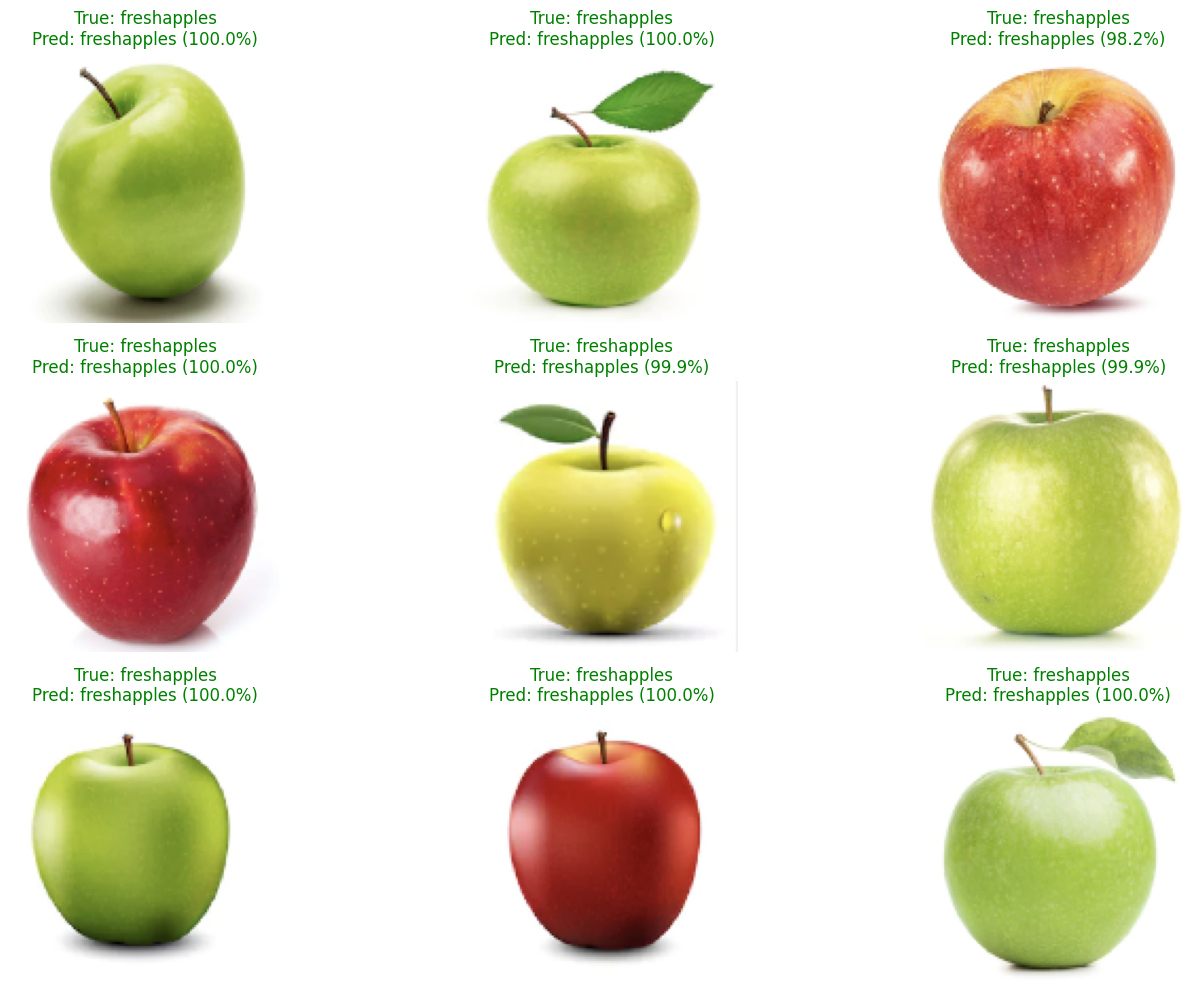

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

test_images, test_labels = next(test_data)

# Sirf ek dafa predict karo, poore batch par
all_preds = transfer_model.predict(test_images)

plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    img = test_images[i]
    true_label = class_names[np.argmax(test_labels[i])]

    pred = all_preds[i]
    pred_label = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()